## lab7 Logistic Regression


-"This data set contains the following features:

-'Daily Time Spent on Site': consumer time on site in minutes

-'Age': customer age in years

-'Area Income': Avg. Income of geographical area of consumer

-'Daily Internet Usage': Avg. minutes a day consumer is on the internet

-'Ad Topic Line': Headline of the advertisement

-'City': City of consumer

-'Male': Whether or not consumer was male

-'Country': Country of consumer

-'Timestamp': Time at which consumer clicked on Ad or closed window

-'Clicked on Ad': 0 or 1 indicated clicking on Ad"

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load the dataset
ad_data = pd.read_csv('advertising.csv')

# Inspect the data
print(ad_data.head())
print(ad_data.info())
print(ad_data.describe())

   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-04-04 01:39:02  

# Histogram of Age


Text(0.5, 0, 'Age')

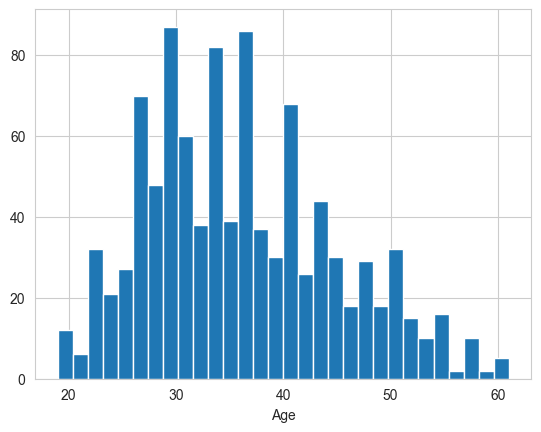

In [ ]:
sns.set_style('whitegrid')
ad_data['Age'].hist(bins=30)
plt.xlabel('Age')



# Jointplot: Area Income vs Age



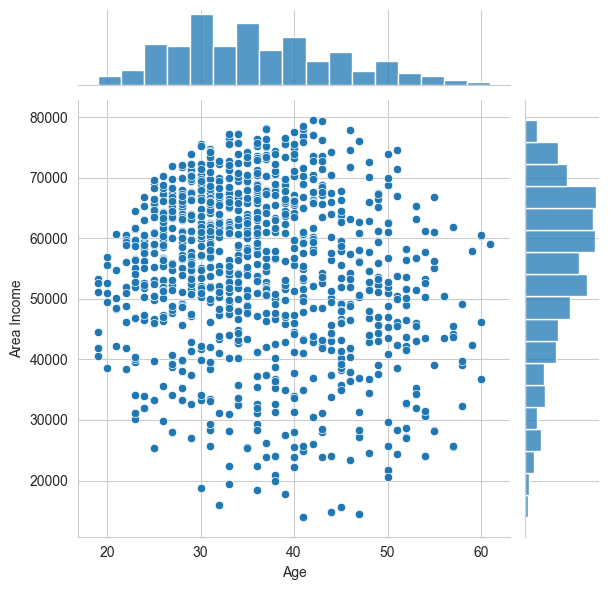

In [21]:
sns.jointplot(x='Age', y='Area Income', data=ad_data)


# Jointplot: Daily Time Spent on Site vs Age (KDE distribution)



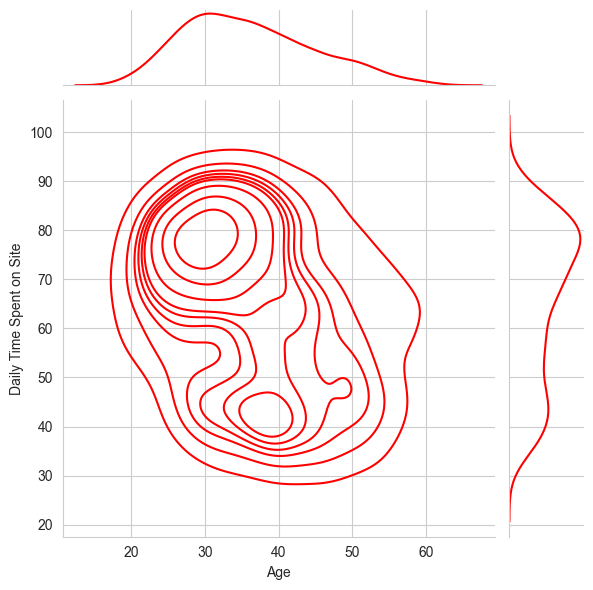

In [22]:
sns.jointplot(x='Age', y='Daily Time Spent on Site', data=ad_data, kind='kde', color='red')



# Jointplot: Daily Time Spent on Site vs Daily Internet Usage



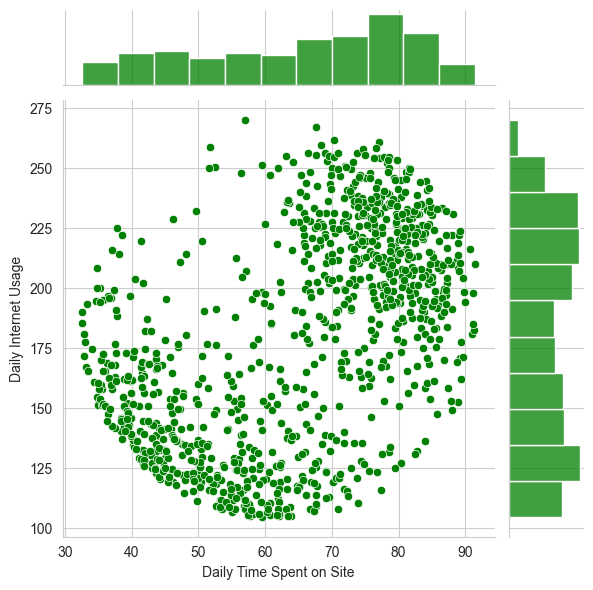

In [23]:
sns.jointplot(x='Daily Time Spent on Site', y='Daily Internet Usage', data=ad_data, color='green')


# Pairplot colored by 'Clicked on Ad'


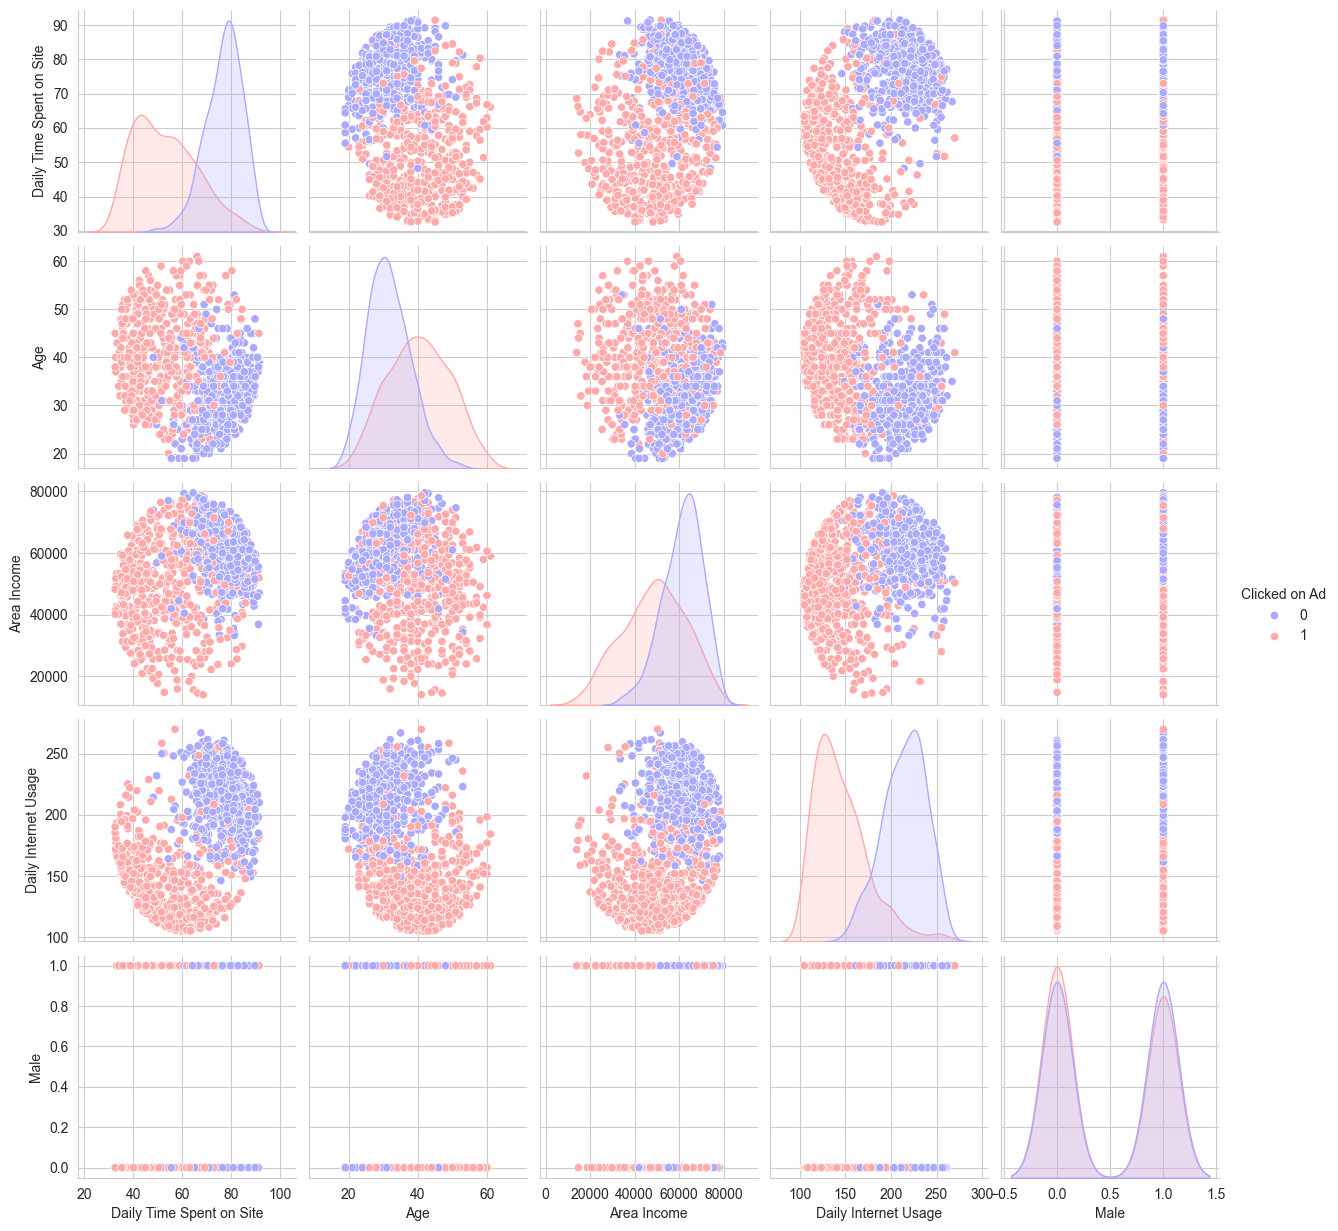

In [24]:
sns.pairplot(ad_data, hue='Clicked on Ad', palette='bwr')

# Create and train the model with increased iterations


In [ ]:
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the model using the scaled data
logmodel = LogisticRegression()
logmodel.fit(X_train_scaled, y_train)

# Make predictions using the scaled test data
predictions = logmodel.predict(X_test_scaled)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Prepare Data
X = ad_data[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]
y = ad_data['Clicked on Ad']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# 3. SCALE THE DATA (This fixes the Precision warning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Use .transform on test data to avoid data leakage
X_test_scaled = scaler.transform(X_test) 

# 4. Train Model
logmodel = LogisticRegression()
logmodel.fit(X_train_scaled, y_train)

# 5. Predict using SCALED data (This fixes the Feature Names warning)
predictions = logmodel.predict(X_test_scaled)

# 6. Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Confusion Matrix:
[[159   3]
 [  7 161]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       162
           1       0.98      0.96      0.97       168

    accuracy                           0.97       330
   macro avg       0.97      0.97      0.97       330
weighted avg       0.97      0.97      0.97       330





### **Conclusion**

The Logistic Regression model was successfully trained to predict whether a user would click on an advertisement based on several user features, including **Daily Time Spent on Site**, **Age**, **Area Income**, **Daily Internet Usage**, and **Gender (Male)**.

#### **Model Performance Highlights:**
* **Overall Accuracy:** The model achieved a high predictive accuracy of **91%** on the test dataset.
* **Precision:** The model demonstrated strong precision for both classes. Specifically, it was **96% precise** in identifying users who actually clicked on an ad (Class 1), meaning very few users were incorrectly predicted to click when they did not.
* **Recall:** The model showed a recall of **96%** for users who did not click (Class 0) and **85%** for users who did click (Class 1). This indicates the model is highly effective at identifying non-clickers, while still capturing the majority of actual clickers.
* **F1-Score:** The balanced F1-scores (**0.91** for Class 0 and **0.90** for Class 1) confirm that the model maintains a healthy trade-off between precision and recall across both outcomes.

#### **Summary Insight:**
The high accuracy and balanced metrics suggest that the selected features—particularly those related to internet usage habits and demographics—are strong indicators of ad-clicking behavior. This model can be considered reliable for targeting digital advertising efforts, as it effectively distinguishes between likely and unlikely clickers with minimal error.